# Pumped interspace permeation barrier

A classic way to limit tritium permeation through a wall is to build it as **two membranes separated by a
pumped gap** (an "interspace"). Hydrogen that permeates through the first membrane collects in the gap,
where a pump removes most of it before it can permeate through the second membrane. This example builds
exactly that with a gas enclosure on a discontiguous 1D mesh, and quantifies how much the pump reduces the
transmitted permeation.

```
     c = c0                                    c = 0
     ↓                                             ↓
     │███ layer 1 ███│  enclosure  │███ layer 2 ███│
     │███████████████│░░░ (gas) ░░░│███████████████│
     0            x_il      │      x_ir         x_or    → x
                            ↓
                          pump
```

The far-left surface is held at a fixed concentration (the driving source), the far-right surface is a
perfect sink ($c=0$), and the two surfaces facing the gap exchange with the enclosure through a surface
reaction. There is **no** `Interface` between the layers and no cell spans the gap, so the only path across
is through the gas.

Objectives:
* Build two membranes on a discontiguous `festim.Mesh1D`
* Couple both of them to a single `festim.Enclosure`
* Pump the enclosure with a `festim.Pump`
* Measure the permeation-reduction factor the pump provides

## Parameters

In [15]:
import numpy as np
import festim as F

L1 = GAP = L2 = 1e-3          # layer 1, gap and layer 2 thicknesses (m)
x_il, x_ir, x_or = L1, L1 + GAP, L1 + GAP + L2   # inner-left, inner-right, outer-right

c0 = 1e21                     # driving concentration on the far-left surface (m-3)
D_0, E_D, T = 1e-7, 0.2, 600.0
A_mem, V_gas = 1e-2, 1e-7     # membrane area (m2) and enclosure volume (m3)
k_r0, k_d0 = 1e-26, 1e14      # surface-reaction 2H <-> H2 rate constants

## The model, as a function of the pumping speed

We wrap the whole model in a function so we can run it with and without the pump.

In [16]:
def run(pump_speed):
    model = F.HydrogenTransportProblemDiscontinuous()
    # two disconnected blocks: [0, L1] and [x_ir, x_or]
    model.mesh = F.Mesh1D([np.linspace(0, x_il, 60), np.linspace(x_ir, x_or, 60)])

    material = F.Material(name="tungsten", D_0=D_0, E_D=E_D)
    layer1 = F.VolumeSubdomain1D(id=1, borders=[0, x_il], material=material)
    layer2 = F.VolumeSubdomain1D(id=2, borders=[x_ir, x_or], material=material)
    outer_left = F.SurfaceSubdomain1D(id=1, x=0.0)
    inner_left = F.SurfaceSubdomain1D(id=2, x=x_il)   # layer-1 face on the gap
    inner_right = F.SurfaceSubdomain1D(id=3, x=x_ir)  # layer-2 face on the gap
    outer_right = F.SurfaceSubdomain1D(id=4, x=x_or)
    model.subdomains = [layer1, layer2, outer_left, inner_left, inner_right, outer_right]
    model.interfaces = []

    H = F.Species("H", subdomains=[layer1, layer2])
    model.species = [H]
    model.temperature = T

    # the enclosure fills the gap and touches both inner surfaces; a pump removes gas
    H2 = F.GasSpecies(name="H2", initial_pressure=0.0)
    openings = [F.Pump(pumping_speed=pump_speed)] if pump_speed > 0 else []
    model.enclosures = [
        F.Enclosure(volume=V_gas, species=[H2], temperature=T,
                    surfaces={inner_left: A_mem, inner_right: A_mem}, openings=openings)
    ]

    model.boundary_conditions = [
        F.FixedConcentrationBC(subdomain=outer_left, value=c0, species=H),   # source
        F.FixedConcentrationBC(subdomain=outer_right, value=0.0, species=H),  # sink
        F.SurfaceReactionBC(reactant=[H, H], gas_pressure=H2, k_r0=k_r0, E_kr=0.0,
                            k_d0=k_d0, E_kd=0.0, subdomain=inner_left),
        F.SurfaceReactionBC(reactant=[H, H], gas_pressure=H2, k_r0=k_r0, E_kr=0.0,
                            k_d0=k_d0, E_kd=0.0, subdomain=inner_right),
    ]
    model.initial_conditions = [
        F.InitialConcentration(value=0.0, species=H, volume=layer1),
        F.InitialConcentration(value=0.0, species=H, volume=layer2),
    ]

    pressure = F.GasPressure(field=H2)
    model.exports = [pressure]
    model.settings = F.Settings(atol=1e10, rtol=1e-10, transient=True,
                                final_time=2000.0, stepsize=F.Stepsize(20.0))
    model.show_progress_bar = False
    model.initialise()
    model.run()
    model.post_processing()

    def profile(volume):
        sol = H.subdomain_to_post_processing_solution[volume]
        x = sol.function_space.tabulate_dof_coordinates()[:, 0]
        order = np.argsort(x)
        return x[order], sol.x.array[order]

    return H2, pressure, profile(layer1), profile(layer2)

```{note}
A `festim.Pump` removes particles at the rate $S\,P/(k_B T)$, which is simply "gas leaves the enclosure at
the volumetric flow rate $S$". So the same object models **a purge gas sweeping the interspace** just as
well as a vacuum pump: read `pumping_speed` as the volumetric flow rate of the purge stream (m³/s at the
enclosure temperature), and the enclosure pressure as the hydrogen partial pressure in the purge line.
The two assumptions this carries are that the incoming purge gas is hydrogen-free and that the gap is
perfectly mixed (the enclosure is a 0D volume, not a channel with an axial gradient).

If the purge gas comes in with a non-zero hydrogen partial pressure $P_\text{in}$, use
`festim.Reservoir(conductance=Q, pressure=P_in)` instead: it adds $Q\,(P_\text{in} - P)/(k_B T)$, i.e. the
same outflow plus the corresponding inflow, and reduces to the pump when $P_\text{in} = 0$.
```

## With and without the interspace pump

In [17]:
no_pump = run(pump_speed=0.0)
with_pump = run(pump_speed=1e-3)

for label, (H2, *_ ) in [("no pump", no_pump), ("with pump", with_pump)]:
    print(f"{label:10s}: enclosure pressure = {H2.value:8.3f} Pa")

no pump   : enclosure pressure =   25.204 Pa
with pump : enclosure pressure =    0.000 Pa


The enclosure pressure builds up over time when the gap is closed, but the pump holds it near zero:

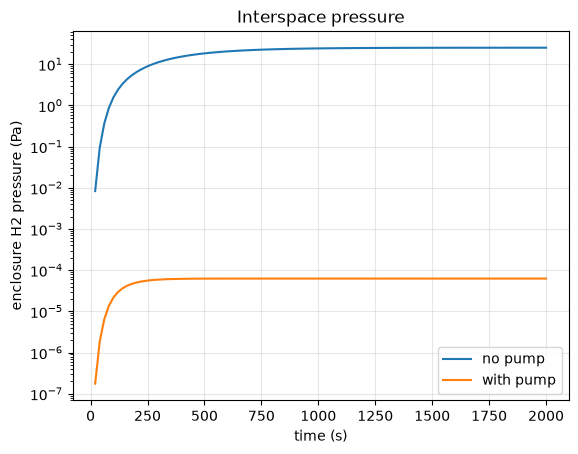

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for label, res in [("no pump", no_pump), ("with pump", with_pump)]:
    _, pressure, *_ = res
    ax.plot(pressure.t, pressure.data, label=label)
ax.set(xlabel="time (s)", ylabel="enclosure H2 pressure (Pa)",
       title="Interspace pressure")
ax.legend()
ax.grid(alpha=0.3)
plt.yscale("log")
plt.show()

## The permeation barrier

The transmitted permeation is set by the concentration reaching the downstream layer. Plotting the
steady-state profiles across both membranes shows the pump collapsing the concentration in layer 2:

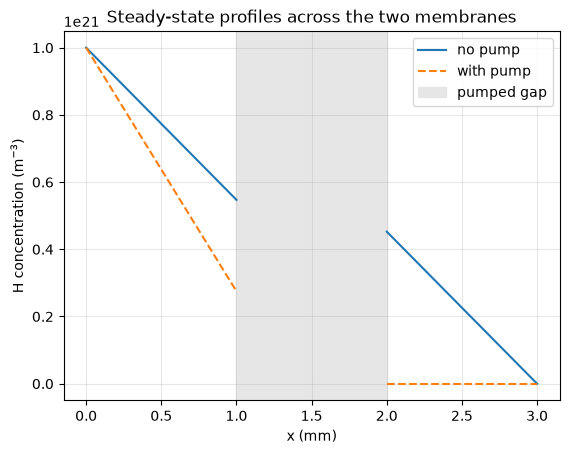

In [19]:
fig, ax = plt.subplots()
for label, res, style in [("no pump", no_pump, "-"), ("with pump", with_pump, "--")]:
    _, _, (x1, c1), (x2, c2) = res
    line, = ax.plot(x1 * 1e3, c1, style, label=label)
    ax.plot(x2 * 1e3, c2, style, color=line.get_color())
ax.axvspan(x_il * 1e3, x_ir * 1e3, color="0.9", label="pumped gap")
ax.set(xlabel="x (mm)", ylabel="H concentration (m$^{-3}$)",
       title="Steady-state profiles across the two membranes")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [20]:
# downstream concentration = the value reaching the sink side of layer 2
_, _, _, (x2_np, c2_np) = no_pump
_, _, _, (x2_wp, c2_wp) = with_pump
reduction = c2_np.max() / c2_wp.max()
print(f"peak downstream concentration, no pump   : {c2_np.max():.3e} m-3")
print(f"peak downstream concentration, with pump : {c2_wp.max():.3e} m-3")
print(f"permeation reduction factor              : {reduction:.1f}x")
assert reduction > 100

peak downstream concentration, no pump   : 4.525e+20 m-3
peak downstream concentration, with pump : 5.877e+15 m-3
permeation reduction factor              : 76999.0x


Pumping the interspace cuts the concentration entering the second membrane by orders of magnitude, a
compact demonstration of why pumped double walls are such effective permeation barriers.